<a href="https://colab.research.google.com/github/Lausabogal22/data_project/blob/main/ElPaso_AirQuality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Data_Set_Air_Quality_elPaso 2026.csv to Data_Set_Air_Quality_elPaso 2026.csv


In [ ]:
import pandas as pd
df = pd.read_csv('Data_Set_Air_Quality_elPaso 2026.csv')

print("rows and columns:", df.shape)
print("\n columns")
print(df.columns.tolist())
print("\n first 5 rows :")
df.head(5)


rows and columns: (912, 22)

 columns
['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']

 first 5 rows :


,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,1/2/2026,AQS,481410044,1,3.3,ug/m3 LC,18,El Paso Chamizal,1,100,...,145.0,R & P Model 2025 PM-2.5 Sequential Air Sampler...,21340,"El Paso, TX",48,Texas,141,El Paso,31.765684,-106.455227
1,1/5/2026,AQS,481410044,1,5.2,ug/m3 LC,29,El Paso Chamizal,1,100,...,145.0,R & P Model 2025 PM-2.5 Sequential Air Sampler...,21340,"El Paso, TX",48,Texas,141,El Paso,31.765684,-106.455227
2,1/8/2026,AQS,481410044,1,2.4,ug/m3 LC,13,El Paso Chamizal,1,100,...,145.0,R & P Model 2025 PM-2.5 Sequential Air Sampler...,21340,"El Paso, TX",48,Texas,141,El Paso,31.765684,-106.455227
3,1/11/2026,AQS,481410044,1,2.2,ug/m3 LC,12,El Paso Chamizal,1,100,...,145.0,R & P Model 2025 PM-2.5 Sequential Air Sampler...,21340,"El Paso, TX",48,Texas,141,El Paso,31.765684,-106.455227
4,1/14/2026,AQS,481410044,1,9.8,ug/m3 LC,52,El Paso Chamizal,1,100,...,145.0,R & P Model 2025 PM-2.5 Sequential Air Sampler...,21340,"El Paso, TX",48,Texas,141,El Paso,31.765684,-106.455227


In [ ]:
df_clean = df[[
    'Date',
    'Daily Mean PM2.5 Concentration',
    'Daily AQI Value',
    'Local Site Name',
    'Site Latitude',
    'Site Longitude'
]].copy()

# Convertir Date a formato fecha
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Ver resumen estadístico
print("📊 Resumen estadístico:")
print(df_clean['Daily Mean PM2.5 Concentration'].describe())

print("\n📍 Estaciones de monitoreo en El Paso:")
print(df_clean['Local Site Name'].unique())

📊 Resumen estadístico:
count    912.000000
mean      10.279386
std        7.006199
min       -0.200000
25%        5.900000
50%        8.550000
75%       13.000000
max       50.500000
Name: Daily Mean PM2.5 Concentration, dtype: float64

📍 Estaciones de monitoreo en El Paso:
['El Paso Chamizal' 'Ascarate Park SE' 'Socorro Hueco' 'Skyline Park']


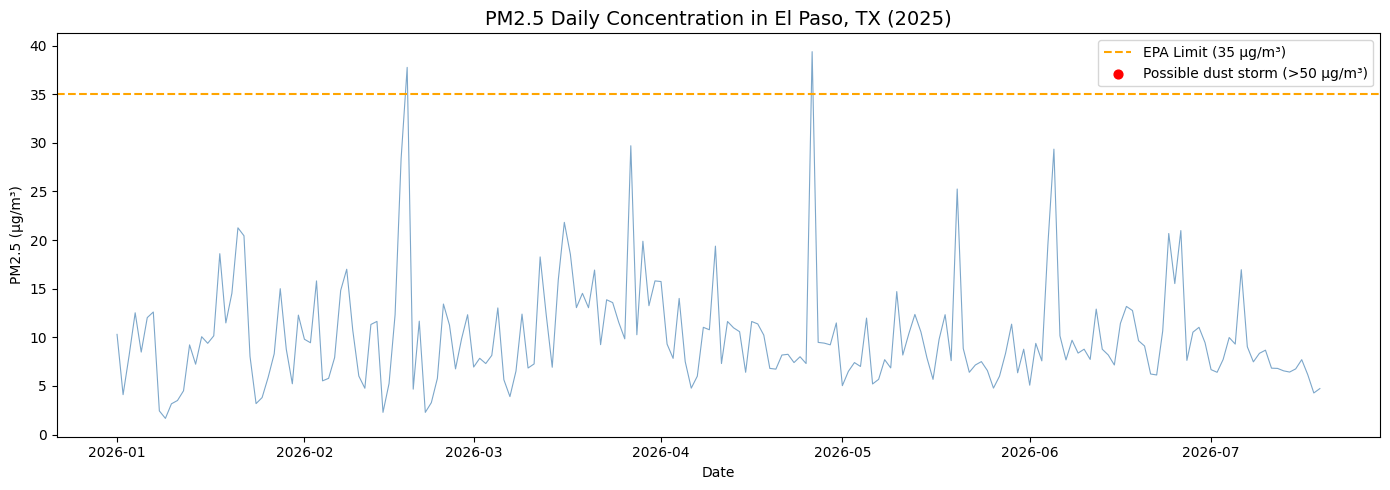


🌪️ Days with possible dust storm activity: 0
Empty DataFrame
Columns: [Date, Daily Mean PM2.5 Concentration]
Index: []


In [ ]:
import matplotlib.pyplot as plt

# Agrupar por fecha - promedio de todas las estaciones
df_daily = df_clean.groupby('Date')['Daily Mean PM2.5 Concentration'].mean().reset_index()

# Graficar
plt.figure(figsize=(14, 5))
plt.plot(df_daily['Date'],
         df_daily['Daily Mean PM2.5 Concentration'],
         color='steelblue', linewidth=0.8, alpha=0.7)

# Línea de referencia - nivel "Unhealthy for Sensitive Groups" EPA
plt.axhline(y=35, color='orange', linestyle='--', linewidth=1.5, label='EPA Limit (35 µg/m³)')

# Marcar picos extremos (posibles dust storms)
threshold = 50
peaks = df_daily[df_daily['Daily Mean PM2.5 Concentration'] > threshold]
plt.scatter(peaks['Date'],
            peaks['Daily Mean PM2.5 Concentration'],
            color='red', s=40, zorder=5, label=f'Possible dust storm (>{threshold} µg/m³)')

plt.title('PM2.5 Daily Concentration in El Paso, TX (2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n🌪️ Days with possible dust storm activity: {len(peaks)}")
print(peaks[['Date', 'Daily Mean PM2.5 Concentration']].sort_values(
    'Daily Mean PM2.5 Concentration', ascending=False).head(10))

In [ ]:
# Ver el rango real de tus datos
print("📅 Rango de fechas:")
print("Desde:", df_clean['Date'].min())
print("Hasta:", df_clean['Date'].max())

print("\n📊 Estadísticas de PM2.5:")
print(df_clean['Daily Mean PM2.5 Concentration'].describe())

print("\n🔝 Los 10 días con PM2.5 más alto:")
top10 = df_daily.sort_values('Daily Mean PM2.5 Concentration', ascending=False).head(10)
print(top10)

📅 Rango de fechas:
Desde: 2026-01-01 00:00:00
Hasta: 2026-07-19 00:00:00

📊 Estadísticas de PM2.5:
count    912.000000
mean      10.279386
std        7.006199
min       -0.200000
25%        5.900000
50%        8.550000
75%       13.000000
max       50.500000
Name: Daily Mean PM2.5 Concentration, dtype: float64

🔝 Los 10 días con PM2.5 más alto:
          Date  Daily Mean PM2.5 Concentration
115 2026-04-26                          39.375
48  2026-02-18                          37.760
85  2026-03-27                          29.700
155 2026-06-05                          29.350
47  2026-02-17                          28.400
139 2026-05-20                          25.250
74  2026-03-16                          21.820
20  2026-01-21                          21.260
176 2026-06-26                          20.975
174 2026-06-24                          20.675


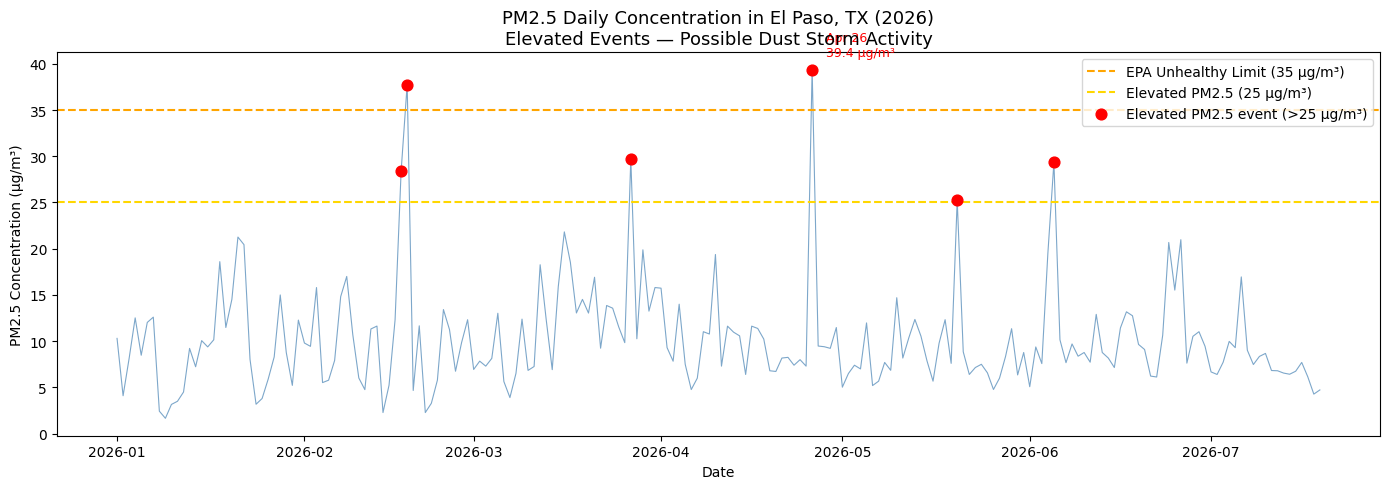


🌪️ Elevated PM2.5 events (>25 µg/m³): 6 days

📅 Event dates:
          Date  Daily Mean PM2.5 Concentration
115 2026-04-26                          39.375
48  2026-02-18                          37.760
85  2026-03-27                          29.700
155 2026-06-05                          29.350
47  2026-02-17                          28.400
139 2026-05-20                          25.250


In [ ]:
# Ajustar threshold a 25 µg/m³ - más realista para PM2.5 en El Paso
threshold = 25

plt.figure(figsize=(14, 5))
plt.plot(df_daily['Date'],
         df_daily['Daily Mean PM2.5 Concentration'],
         color='steelblue', linewidth=0.8, alpha=0.7)

# Zona de alerta EPA
plt.axhline(y=35, color='orange', linestyle='--',
            linewidth=1.5, label='EPA Unhealthy Limit (35 µg/m³)')
plt.axhline(y=25, color='gold', linestyle='--',
            linewidth=1.5, label='Elevated PM2.5 (25 µg/m³)')

# Marcar picos
peaks = df_daily[df_daily['Daily Mean PM2.5 Concentration'] > threshold]
plt.scatter(peaks['Date'],
            peaks['Daily Mean PM2.5 Concentration'],
            color='red', s=60, zorder=5,
            label=f'Elevated PM2.5 event (>{threshold} µg/m³)')

# Anotar el pico más alto
max_day = df_daily.loc[df_daily['Daily Mean PM2.5 Concentration'].idxmax()]
plt.annotate(f"Apr 26\n{max_day['Daily Mean PM2.5 Concentration']:.1f} µg/m³",
             xy=(max_day['Date'], max_day['Daily Mean PM2.5 Concentration']),
             xytext=(10, 10), textcoords='offset points',
             fontsize=9, color='red')

plt.title('PM2.5 Daily Concentration in El Paso, TX (2026)\nElevated Events — Possible Dust Storm Activity',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n🌪️ Elevated PM2.5 events (>{threshold} µg/m³): {len(peaks)} days")
print("\n📅 Event dates:")
print(peaks[['Date', 'Daily Mean PM2.5 Concentration']].sort_values(
    'Daily Mean PM2.5 Concentration', ascending=False))